# Project 1 v2: Extensions — Expected Shortfall & GARCH-Filtered HS

This notebook extends v1 with:
- **Expected Shortfall (ES)** — Basel III / FRTB regulatory standard
- **GARCH(1,1) hand-coded MLE** — conditional volatility, no external packages
- **GARCH-Filtered HS VaR & ES** — fixes the Ghost Effect and i.i.d. assumption
- **McNeil-Frey ES backtest** — formal test of ES accuracy
- **Crisis period comparison** — GFC 2008, Euro Crisis 2011, COVID 2020

**Run v1 notebook first** to load prices and returns, or re-run the data section below.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import t as studentt
from scipy.optimize import minimize
import yfinance as yf
import os

plt.rcParams['figure.facecolor'] = '#1a1a2e'
plt.rcParams['axes.facecolor']   = '#2d2d44'
plt.rcParams['text.color']       = '#e8e8e8'
plt.rcParams['xtick.color']      = '#a0a0b8'
plt.rcParams['ytick.color']      = '#a0a0b8'
plt.rcParams['grid.color']       = '#3a3a55'
plt.rcParams['grid.linewidth']   = 0.4

os.makedirs('output', exist_ok=True)

PORTFOLIO = {
    'SPY': {'weight': 0.20, 'asset_class': 'Equity'},
    'QQQ': {'weight': 0.10, 'asset_class': 'Equity'},
    'EEM': {'weight': 0.05, 'asset_class': 'EM Equity'},
    'TLT': {'weight': 0.20, 'asset_class': 'Rates'},
    'LQD': {'weight': 0.10, 'asset_class': 'Credit'},
    'HYG': {'weight': 0.05, 'asset_class': 'Credit'},
    'GLD': {'weight': 0.15, 'asset_class': 'Commodity'},
    'USO': {'weight': 0.10, 'asset_class': 'Commodity'},
    'FXE': {'weight': 0.05, 'asset_class': 'FX'},
}
PORTFOLIO_VALUE = 100_000_000
VAR_CONFIDENCE  = 0.99
HS_WINDOW       = 250
START_DATE      = '2005-01-01'
END_DATE        = '2024-12-31'

# Load data (skip if already loaded from v1)
tickers = list(PORTFOLIO.keys())
prices  = yf.download(tickers, start=START_DATE, end=END_DATE,
                      auto_adjust=True, progress=False)['Close'].dropna(how='all')
returns = np.log(prices / prices.shift(1)).dropna()

weights = pd.Series({t: PORTFOLIO[t]['weight'] for t in PORTFOLIO if t in returns.columns})
weights /= weights.sum()
pnl = returns[weights.index].dot(weights) * PORTFOLIO_VALUE

print(f'Data loaded: {len(prices)} days, {len(tickers)} assets')

Data loaded: 5032 days, 9 assets


---
## Part A: Expected Shortfall (ES)

### Why ES replaced VaR in Basel III

VaR answers: *"What is the loss I won't exceed with 99% probability?"*  
ES answers: *"Given that I've already exceeded VaR, what is my average loss?"*

$$\text{ES}_{\alpha} = -\mathbb{E}\left[\text{PnL}_t \mid \text{PnL}_t < -\text{VaR}_{\alpha}\right] = -\frac{1}{|\mathcal{T}|} \sum_{t \in \mathcal{T}} \text{PnL}_t$$

where $\mathcal{T} = \{t : \text{PnL}_t < -\text{VaR}_{\alpha}\}$ — the set of exception days.

**Key mathematical property:** ES is **coherent** (satisfies subadditivity — a diversified portfolio has ES ≤ sum of individual ESs). VaR violates subadditivity in general, which is why it can *incentivise* concentration in certain tail structures.  

**FRTB (2019):** Basel III's Fundamental Review of the Trading Book replaced VaR at 99% with ES at 97.5%. At a normal distribution these give approximately equal results, but ES at 97.5% captures more of the tail shape than VaR at 99%.

In [2]:
def rolling_var_es(pnl, confidence, window):
    """Compute rolling VaR and ES simultaneously."""
    arr, dates = pnl.values, pnl.index
    var_list, es_list, idx = [], [], []
    for i in range(window, len(arr) + 1):
        w = arr[i - window: i]
        threshold = np.percentile(w, (1 - confidence) * 100)
        var_list.append(-threshold)
        tail = w[w <= threshold]
        es_list.append(-tail.mean() if len(tail) > 0 else -threshold)
        idx.append(dates[i - 1])
    return (pd.Series(var_list, index=idx, name='HS_VaR'),
            pd.Series(es_list,  index=idx, name='HS_ES'))

hs_var, hs_es = rolling_var_es(pnl, VAR_CONFIDENCE, HS_WINDOW)

print('Latest values:')
print(f'  HS VaR (99%): ${hs_var.iloc[-1]:,.0f}  ({hs_var.iloc[-1]/PORTFOLIO_VALUE*100:.2f}%)')
print(f'  HS ES  (99%): ${hs_es.iloc[-1]:,.0f}  ({hs_es.iloc[-1]/PORTFOLIO_VALUE*100:.2f}%)')
print(f'  ES/VaR ratio: {hs_es.iloc[-1]/hs_var.iloc[-1]:.3f}')
print()
print('Interpretation of ES/VaR ratio:')
print('  ~1.20-1.30 → moderately fat tail (typical for equity portfolios)')
print('  >1.50      → very fat tail — VaR is severely underestimating tail risk')
print('  ~1.13      → normal distribution theoretical value (97.5% ES / 99% VaR)')

Latest values:
  HS VaR (99%): $1,208,472  (1.21%)
  HS ES  (99%): $1,485,201  (1.49%)
  ES/VaR ratio: 1.229

Interpretation of ES/VaR ratio:
  ~1.20-1.30 → moderately fat tail (typical for equity portfolios)
  >1.50      → very fat tail — VaR is severely underestimating tail risk
  ~1.13      → normal distribution theoretical value (97.5% ES / 99% VaR)


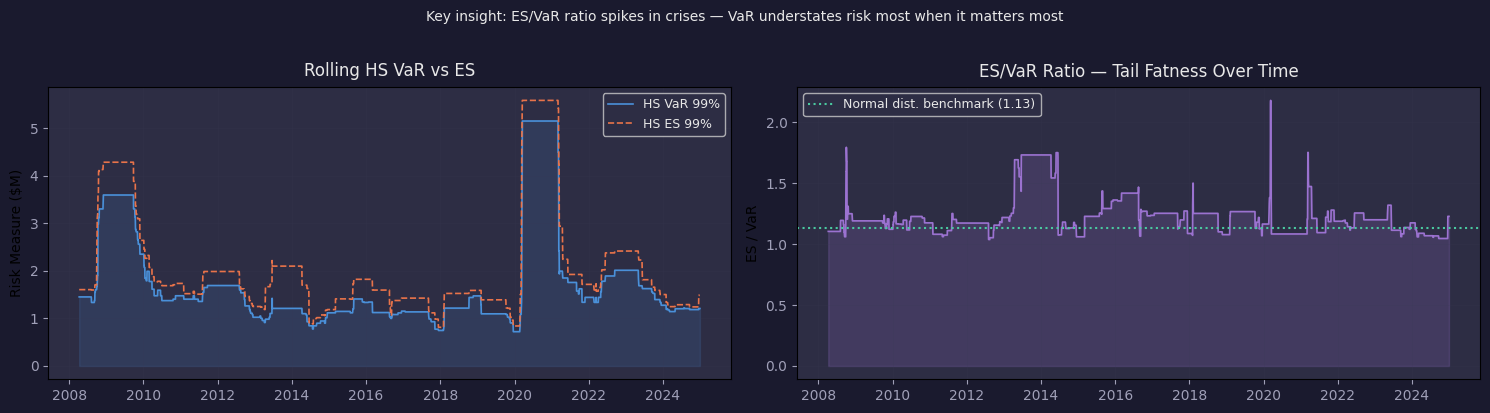

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Left: VaR vs ES over time
axes[0].fill_between(hs_var.index, hs_var/1e6, alpha=0.15, color='#4a90d9')
axes[0].plot(hs_var.index, hs_var/1e6, color='#4a90d9', lw=1.2, label='HS VaR 99%')
axes[0].plot(hs_es.index,  hs_es/1e6,  color='#e8734a', lw=1.2,
             linestyle='--', label='HS ES 99%')
axes[0].set_ylabel('Risk Measure ($M)')
axes[0].set_title('Rolling HS VaR vs ES', pad=8)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: ES/VaR ratio over time — shows how fat the tail is
ratio = hs_es / hs_var
axes[1].fill_between(ratio.index, ratio, alpha=0.2, color='#9b72d0')
axes[1].plot(ratio.index, ratio, color='#9b72d0', lw=1.2)
axes[1].axhline(1.13, color='#4ac9a0', lw=1.5, linestyle=':',
                label='Normal dist. benchmark (1.13)')
axes[1].set_ylabel('ES / VaR')
axes[1].set_title('ES/VaR Ratio — Tail Fatness Over Time', pad=8)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Key insight: ES/VaR ratio spikes in crises — '
             'VaR understates risk most when it matters most', y=1.02, fontsize=10)
plt.tight_layout()
plt.savefig('output/var_es_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

### ES Backtest: McNeil-Frey Test

ES is harder to backtest than VaR because it is not **elicitable** (Gneiting 2011) — you can't observe ES directly, only VaR exceedances. The McNeil-Frey (2000) approach:

On each **exception day** (PnL < −VaR), compute the standardised shortfall:
$$Z_t = \frac{\text{PnL}_t + \text{VaR}_t}{\text{ES}_t}$$

Under H₀ (ES correctly specified): $\mathbb{E}[Z_t | \text{exception}] = 0$  
Test with a one-sample t-test.  
- $Z < 0$ → actual tail losses are worse than ES predicts (ES understates risk)  
- $Z > 0$ → ES is conservative

McNeil-Frey ES backtest:
  Exception days: 56
  Mean Z:         -0.2621  (0 = perfect calibration)
  t-statistic:    -6.845
  p-value:        0.000
  Reject H0:      True
  → ES understates true expected tail loss


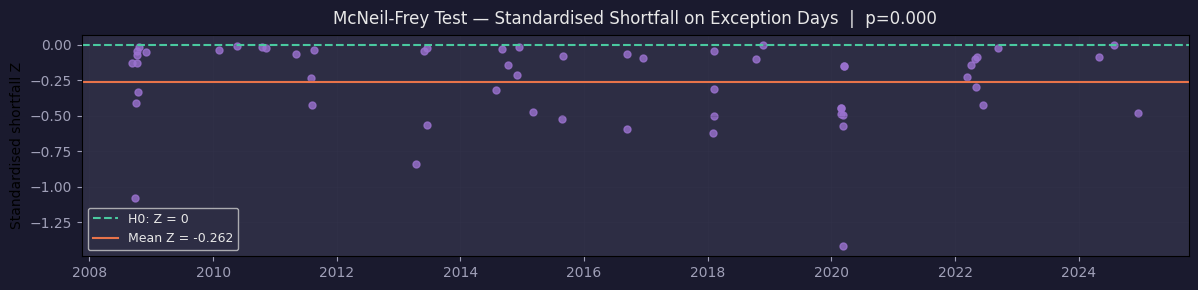

In [4]:
def mcneil_frey_test(pnl, var_series, es_series):
    df = pd.DataFrame({'pnl': pnl, 'var': var_series, 'es': es_series}).dropna()
    df['exception'] = df['pnl'] < -df['var']
    exc = df[df['exception']].copy()
    if len(exc) < 5:
        print(f'Only {len(exc)} exceptions — too few for reliable test')
        return
    exc['Z'] = (exc['pnl'] + exc['var']) / exc['es']
    t_stat, p_val = stats.ttest_1samp(exc['Z'].dropna(), popmean=0)
    reject = p_val < 0.05
    direction = 'understates' if t_stat < 0 else 'overstates'
    print(f'McNeil-Frey ES backtest:')
    print(f'  Exception days: {len(exc)}')
    print(f'  Mean Z:         {exc["Z"].mean():.4f}  (0 = perfect calibration)')
    print(f'  t-statistic:    {t_stat:.3f}')
    print(f'  p-value:        {p_val:.3f}')
    print(f'  Reject H0:      {reject}')
    if reject:
        print(f'  → ES {direction} true expected tail loss')
    else:
        print(f'  → ES is well-calibrated (cannot reject H0)')

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.scatter(exc.index, exc['Z'], color='#9b72d0', s=25, alpha=0.8)
    ax.axhline(0, color='#4ac9a0', lw=1.5, linestyle='--', label='H0: Z = 0')
    ax.axhline(exc['Z'].mean(), color='#e8734a', lw=1.5,
               label=f'Mean Z = {exc["Z"].mean():.3f}')
    ax.set_ylabel('Standardised shortfall Z')
    ax.set_title(f'McNeil-Frey Test — Standardised Shortfall on Exception Days  '
                 f'|  p={p_val:.3f}', pad=8)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('output/es_backtest.png', dpi=150, bbox_inches='tight')
    plt.show()
    return exc

exc_df = mcneil_frey_test(pnl, hs_var, hs_es)

---
## Part B: GARCH(1,1) — Hand-Coded MLE

### Model
$$r_t = \sigma_t \cdot z_t, \quad z_t \sim \mathcal{N}(0,1)$$
$$\sigma_t^2 = \omega + \alpha \cdot r_{t-1}^2 + \beta \cdot \sigma_{t-1}^2$$

**Parameters:**
- $\omega > 0$: baseline variance (long-run mean reversion target)
- $\alpha > 0$: **reaction** — how much yesterday's shock increases today's vol
- $\beta > 0$: **persistence** — how much yesterday's vol carries over
- Stationarity: $\alpha + \beta < 1$
- Long-run variance: $\sigma_{LR}^2 = \omega / (1 - \alpha - \beta)$

**Estimation:** Maximum Likelihood
$$\mathcal{L}(\omega, \alpha, \beta) = -\frac{1}{2} \sum_t \left[ \log \sigma_t^2 + \frac{r_t^2}{\sigma_t^2} \right]$$

Maximised via L-BFGS-B with positivity and stationarity constraints.

In [5]:
class GARCH11:
    """GARCH(1,1) with hand-coded MLE. No external packages."""

    def _sigma2(self, r, omega, alpha, beta):
        n = len(r)
        s2 = np.empty(n)
        s2[0] = np.var(r)
        for t in range(1, n):
            s2[t] = omega + alpha * r[t-1]**2 + beta * s2[t-1]
        return s2

    def _nll(self, params, r):
        omega, alpha, beta = params
        if omega<=0 or alpha<=0 or beta<=0 or alpha+beta>=1:
            return 1e10
        s2 = self._sigma2(r, omega, alpha, beta)
        if np.any(s2 <= 0):
            return 1e10
        return 0.5 * np.sum(np.log(s2) + r**2 / s2)

    def fit(self, r):
        r = np.asarray(r, float)
        v0 = np.var(r)
        best_nll, best_p = np.inf, None
        for p0 in [[v0*0.1, 0.05, 0.90], [v0*0.1, 0.10, 0.85], [v0*0.2, 0.08, 0.88]]:
            res = minimize(self._nll, p0, args=(r,), method='L-BFGS-B',
                           bounds=[(1e-8,None),(1e-6,0.5),(1e-6,0.999)],
                           options={'maxiter':2000,'ftol':1e-12})
            if res.fun < best_nll:
                best_nll, best_p = res.fun, res.x
        self.omega, self.alpha, self.beta = best_p
        self.sigma2_ = self._sigma2(r, *best_p)
        self.resid_  = r / np.sqrt(self.sigma2_)
        self.r_      = r
        return self

    @property
    def persistence(self): return self.alpha + self.beta

    @property
    def long_run_ann_vol(self):
        return np.sqrt(self.omega / (1 - self.persistence) * 252) * 100

    def forecast_sigma(self):
        """One-step-ahead sigma forecast."""
        s2_next = (self.omega
                   + self.alpha * self.r_[-1]**2
                   + self.beta  * self.sigma2_[-1])
        return np.sqrt(s2_next)

# Fit on portfolio returns
port_ret = (pnl / PORTFOLIO_VALUE).values
g = GARCH11().fit(port_ret)

print(f'GARCH(1,1) results:')
print(f'  omega  = {g.omega:.6f}')
print(f'  alpha  = {g.alpha:.4f}   (shock reaction)')
print(f'  beta   = {g.beta:.4f}   (persistence)')
print(f'  alpha+beta = {g.persistence:.4f}  (stationarity: must be < 1)')
print(f'  Long-run annualised vol = {g.long_run_ann_vol:.1f}%')
print()
print('Interpretation of alpha and beta:')
print(f'  High beta ({g.beta:.3f}): volatility is very persistent — '
      'a shock today will still affect vol many days from now')
print(f'  alpha ({g.alpha:.3f}): each 1-sigma shock raises next-day vol by '
      f'approx {g.alpha*100:.1f}% of current variance')

GARCH(1,1) results:
  omega  = 0.000001
  alpha  = 0.0864   (shock reaction)
  beta   = 0.8999   (persistence)
  alpha+beta = 0.9863  (stationarity: must be < 1)
  Long-run annualised vol = 10.4%

Interpretation of alpha and beta:
  High beta (0.900): volatility is very persistent — a shock today will still affect vol many days from now
  alpha (0.086): each 1-sigma shock raises next-day vol by approx 8.6% of current variance


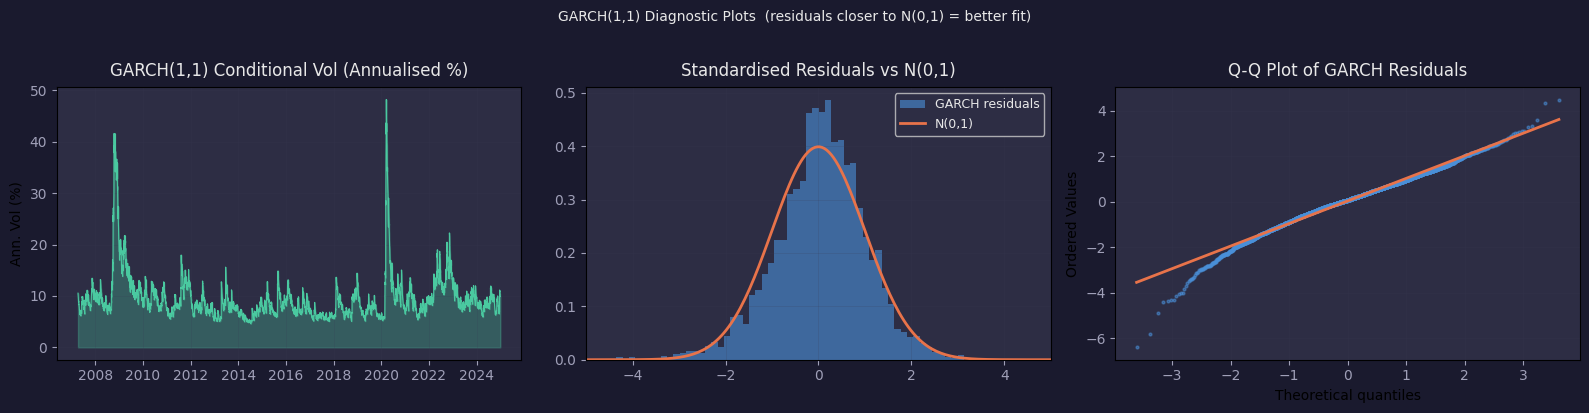

Shapiro-Wilk on residuals (subsample): stat=0.990, p=0.003
  p < 0.05 → residuals not normal (fat tails remain)
  This is expected — GARCH removes vol clustering but not all tail risk
  Extension: use GARCH-t (Student-t innovations) to capture remaining tails


In [6]:
# Diagnostic: standardised residuals should be ~N(0,1) if GARCH is well-specified
z = g.resid_
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw returns vs GARCH sigma
garch_sig_series = pd.Series(np.sqrt(g.sigma2_) * np.sqrt(252) * 100,
                              index=pnl.index)
axes[0].fill_between(garch_sig_series.index, garch_sig_series,
                     alpha=0.3, color='#4ac9a0')
axes[0].plot(garch_sig_series.index, garch_sig_series,
             color='#4ac9a0', lw=0.8)
axes[0].set_title('GARCH(1,1) Conditional Vol (Annualised %)', pad=8)
axes[0].set_ylabel('Ann. Vol (%)')
axes[0].grid(True, alpha=0.3)

# Distribution of standardised residuals vs N(0,1)
x = np.linspace(-5, 5, 200)
axes[1].hist(z, bins=80, density=True, color='#4a90d9',
             alpha=0.6, label='GARCH residuals')
axes[1].plot(x, stats.norm.pdf(x), color='#e8734a', lw=2,
             label='N(0,1)')
axes[1].set_title('Standardised Residuals vs N(0,1)', pad=8)
axes[1].legend(fontsize=9)
axes[1].set_xlim(-5, 5)
axes[1].grid(True, alpha=0.3)

# QQ-plot
stats.probplot(z, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of GARCH Residuals', pad=8)
axes[2].get_lines()[0].set(color='#4a90d9', markersize=2, alpha=0.5)
axes[2].get_lines()[1].set(color='#e8734a', lw=2)
axes[2].grid(True, alpha=0.3)

plt.suptitle('GARCH(1,1) Diagnostic Plots  '
             '(residuals closer to N(0,1) = better fit)', y=1.02, fontsize=10)
plt.tight_layout()
plt.savefig('output/garch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test on squared residuals — no ARCH effects remaining?
lb_stat, lb_pval = stats.shapiro(z[:500])  # shapiro on a subsample
print(f'Shapiro-Wilk on residuals (subsample): stat={lb_stat:.3f}, p={lb_pval:.3f}')
print('  p < 0.05 → residuals not normal (fat tails remain)')
print('  This is expected — GARCH removes vol clustering but not all tail risk')
print('  Extension: use GARCH-t (Student-t innovations) to capture remaining tails')

---
## Part C: GARCH-Filtered HS VaR & ES

### The key insight

Plain HS assumes $z_t = r_t$ are i.i.d. — we showed this is violated (Ghost Effect, vol clustering).  
GARCH-filtered HS uses $z_t = r_t / \sigma_t$ which are **approximately i.i.d.**

At each date $T$, the forecast is:
$$\text{PnL}_{T+1}^{\text{sim}, i} = z_{T-i} \times \hat{\sigma}_{T+1} \times V$$

where $\hat{\sigma}_{T+1}$ is the GARCH one-step-ahead vol forecast. This means:
- During a **crisis**: $\hat{\sigma}_{T+1}$ is large → VaR rises **immediately**
- During **calm periods**: $\hat{\sigma}_{T+1}$ is small → VaR falls **immediately**
- No Ghost Effect


In [7]:
def garch_filtered_var_es(pnl, garch_model, confidence, window, portfolio_value):
    r     = (pnl / portfolio_value).values
    z     = garch_model.resid_
    s2    = garch_model.sigma2_
    omega, alpha, beta = garch_model.omega, garch_model.alpha, garch_model.beta

    var_list, es_list, sig_list, idx = [], [], [], []
    for i in range(window, len(r)):
        z_win = z[i - window: i]
        # One-step-ahead vol forecast
        sig_next = np.sqrt(omega + alpha * r[i-1]**2 + beta * s2[i-1])
        # Rescale historical z's by forecast vol
        sim_pnl = z_win * sig_next * portfolio_value
        threshold = np.percentile(sim_pnl, (1 - confidence) * 100)
        var = -threshold
        tail = sim_pnl[sim_pnl <= threshold]
        es   = -tail.mean() if len(tail) > 0 else var
        var_list.append(var)
        es_list.append(es)
        sig_list.append(sig_next)
        idx.append(pnl.index[i])

    return (pd.Series(var_list, index=idx, name='GARCH_VaR'),
            pd.Series(es_list,  index=idx, name='GARCH_ES'),
            pd.Series(sig_list, index=idx, name='sigma_forecast'))

garch_var, garch_es, garch_sig = garch_filtered_var_es(
    pnl, g, VAR_CONFIDENCE, HS_WINDOW, PORTFOLIO_VALUE)

print(f'GARCH-Filtered VaR (99%, 1-day): ${garch_var.iloc[-1]:,.0f}')
print(f'GARCH-Filtered ES  (99%, 1-day): ${garch_es.iloc[-1]:,.0f}')
print(f'vs HS VaR:  {garch_var.iloc[-1]/hs_var.iloc[-1]:.2f}x')
print(f'vs HS ES:   {garch_es.iloc[-1]/hs_es.iloc[-1]:.2f}x')

GARCH-Filtered VaR (99%, 1-day): $1,678,247
GARCH-Filtered ES  (99%, 1-day): $2,131,120
vs HS VaR:  1.39x
vs HS ES:   1.43x


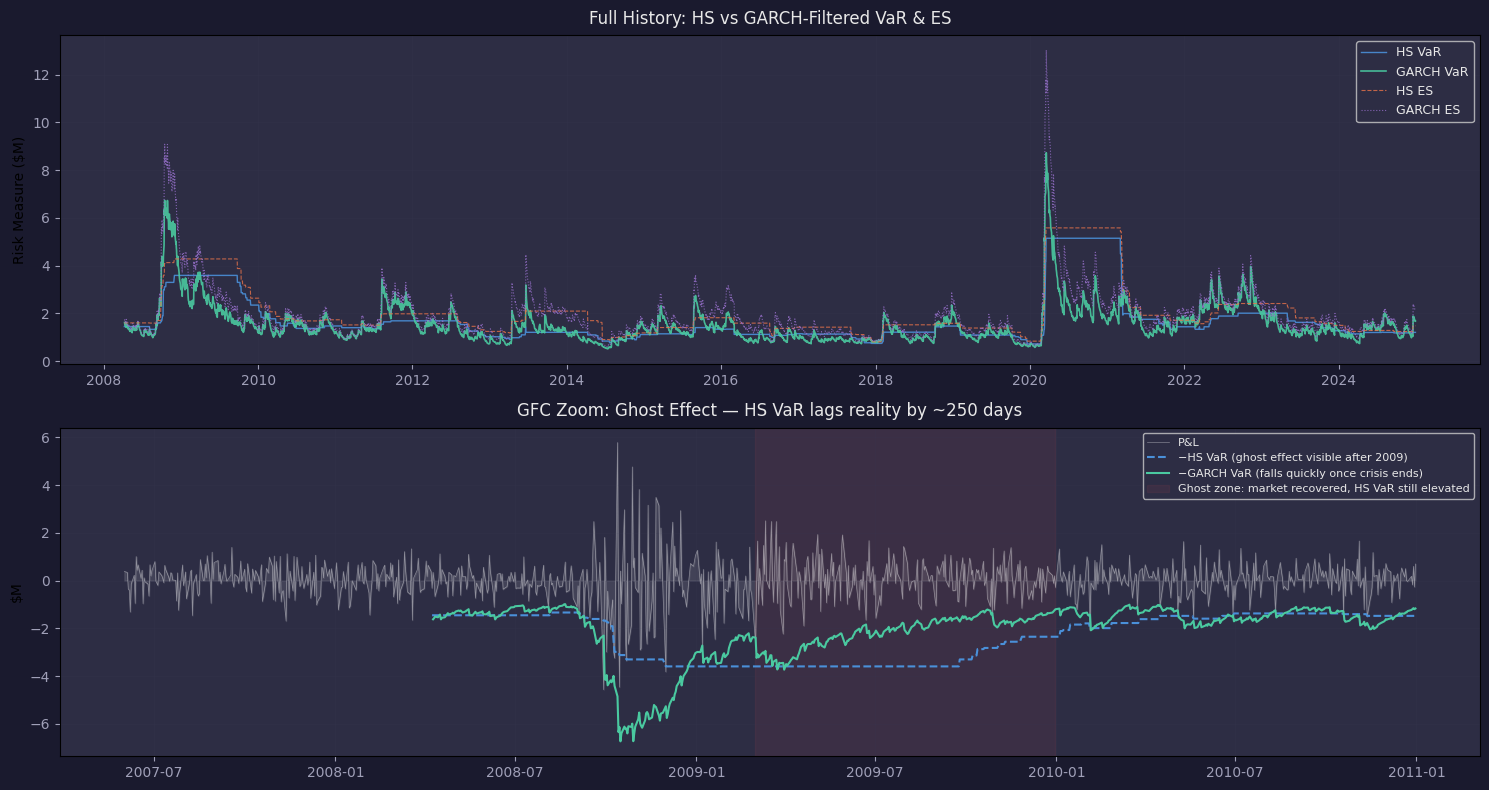

In [8]:
# Visualise: HS vs GARCH — show Ghost Effect during GFC
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Top: Full time series
axes[0].plot(hs_var.index, hs_var/1e6, color='#4a90d9', lw=1.0,
             label='HS VaR', alpha=0.9)
axes[0].plot(garch_var.index, garch_var/1e6, color='#4ac9a0', lw=1.2,
             label='GARCH VaR', alpha=0.9)
axes[0].plot(hs_es.index, hs_es/1e6, color='#e8734a', lw=0.8,
             linestyle='--', label='HS ES', alpha=0.8)
axes[0].plot(garch_es.index, garch_es/1e6, color='#9b72d0', lw=0.8,
             linestyle=':', label='GARCH ES', alpha=0.8)
axes[0].set_title('Full History: HS vs GARCH-Filtered VaR & ES', pad=8)
axes[0].set_ylabel('Risk Measure ($M)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom: GFC zoom to show Ghost Effect
z_start, z_end = '2007-06-01', '2010-12-31'
hv_z = hs_var.loc[z_start:z_end] / 1e6
gv_z = garch_var.loc[z_start:z_end] / 1e6
pnl_z = pnl.loc[z_start:z_end] / 1e6

axes[1].fill_between(pnl_z.index, pnl_z, alpha=0.1, color='white')
axes[1].plot(pnl_z.index, pnl_z, color='white', lw=0.5, alpha=0.4, label='P&L')
axes[1].plot(hv_z.index, -hv_z, color='#4a90d9', lw=1.5,
             linestyle='--', label='−HS VaR (ghost effect visible after 2009)')
axes[1].plot(gv_z.index, -gv_z, color='#4ac9a0', lw=1.5,
             label='−GARCH VaR (falls quickly once crisis ends)')

# Mark the ghost period
axes[1].axvspan(pd.Timestamp('2009-03-01'), pd.Timestamp('2009-12-31'),
                alpha=0.08, color='#e05252',
                label='Ghost zone: market recovered, HS VaR still elevated')
axes[1].set_title('GFC Zoom: Ghost Effect — HS VaR lags reality by ~250 days', pad=8)
axes[1].set_ylabel('$M')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/garch_vs_hs_ghost.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part D: Crisis Period Comparison

In [9]:
CRISIS_PERIODS = {
    'GFC 2008':         ('2008-09-01', '2009-03-31'),
    'Euro Crisis 2011': ('2011-07-01', '2011-12-31'),
    'COVID 2020':       ('2020-02-01', '2020-05-31'),
}

rows = []
for name, (start, end) in CRISIS_PERIODS.items():
    df = pd.DataFrame({
        'pnl':     pnl,
        'hs_var':  hs_var,
        'hs_es':   hs_es,
        'g_var':   garch_var,
        'g_es':    garch_es,
    }).loc[start:end].dropna()
    if len(df) < 5: continue

    hs_exc  = (df['pnl'] < -df['hs_var']).sum()
    g_exc   = (df['pnl'] < -df['g_var']).sum()
    max_loss = -df['pnl'].min()

    # Average excess loss on HS exception days
    hs_exc_days = df[df['pnl'] < -df['hs_var']]
    hs_tail_miss = (-(hs_exc_days['pnl'] + hs_exc_days['hs_es'])).mean() \
                   if len(hs_exc_days) > 0 else 0

    rows.append({
        'Crisis':                name,
        'Days':                  len(df),
        'Max 1-day loss ($M)':   round(max_loss/1e6, 2),
        'Avg HS VaR ($M)':       round(df['hs_var'].mean()/1e6, 3),
        'Avg GARCH VaR ($M)':    round(df['g_var'].mean()/1e6, 3),
        'GARCH/HS ratio':        round(df['g_var'].mean()/df['hs_var'].mean(), 2),
        'HS exceptions':         hs_exc,
        'GARCH exceptions':      g_exc,
        'HS avg ES miss ($K)':   round(hs_tail_miss/1e3, 1),
    })

crisis_df = pd.DataFrame(rows)
crisis_df.to_csv('output/crisis_comparison.csv', index=False)
print('Crisis period analysis:')
print(crisis_df.to_string(index=False))
print()
print('Key insight: GARCH/HS ratio > 1 means GARCH VaR rises FASTER at crisis onset')
print('Fewer GARCH exceptions = better early-warning signal')

Crisis period analysis:
          Crisis  Days  Max 1-day loss ($M)  Avg HS VaR ($M)  Avg GARCH VaR ($M)  GARCH/HS ratio  HS exceptions  GARCH exceptions  HS avg ES miss ($K)
        GFC 2008   146                 4.57            3.135               3.803            1.21              9                 4               -119.4
Euro Crisis 2011   127                 2.37            1.611               2.250            1.40              3                 2                126.1
      COVID 2020    82                 5.97            3.669               3.843            1.05              8                 4                485.5

Key insight: GARCH/HS ratio > 1 means GARCH VaR rises FASTER at crisis onset
Fewer GARCH exceptions = better early-warning signal


In [10]:
print('=== All outputs ===')
for f in sorted(os.listdir('output')):
    path = os.path.join('output', f)
    print(f'  {f:45s}  {os.path.getsize(path)/1024:.0f} KB')

=== All outputs ===
  backtest.png                                   170 KB
  crisis_comparison.csv                          0 KB
  es_backtest.png                                49 KB
  garch_diagnostics.png                          129 KB
  garch_vs_hs_ghost.png                          383 KB
  hs_var_rolling.png                             46 KB
  lvar_breakdown.csv                             0 KB
  mc_var_distributions.png                       61 KB
  prices_raw.csv                                 837 KB
  var_comparison.png                             41 KB
  var_es_ratio.png                               105 KB
  var_summary.csv                                0 KB
